Варіант 6
Місто Чернігів

=== Сформований набір даних (Варіант 6 — Чернігів) ===
   день  вихідний  температура  продажі
0     1     False          2.4       30
1     2     False         -1.0       34
2     3     False          1.9       30
3     4     False         -2.7       44
4     5     False         -2.4       40
5     6      True          0.6       36
6     7      True          0.2       42
7     8     False         -0.5       37
8     9     False         -1.0       34
9    10     False          0.7       28




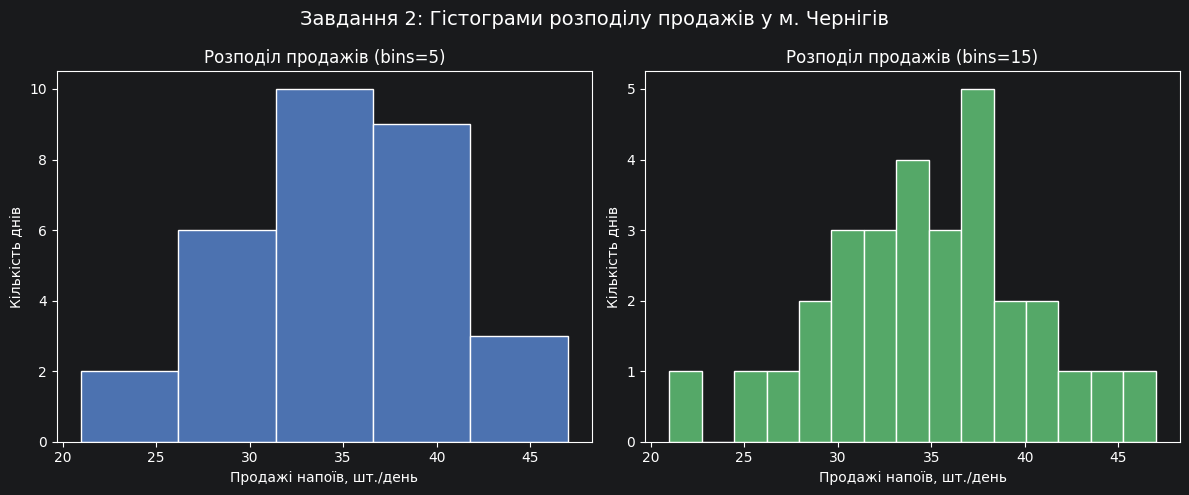


[Аналіз до Завдання 2]
Для вибірки з 30 значень більш змістовну картину дає параметр bins=5 (або bins=6).
Чому:
При bins=15 на 30 спостережень припадає в середньому лише по 2 значення на один інтервал.
Це призводить до розривчастого ("гребінчастого") графіка із забагатою кількістю порожніх інтервалів,
що є наслідком шуму у вибірці, а не реальної форми розподілу.
Bins=5 гармонійно агрегує дані, чітко показуючи загальну тенденцію, центральну тенденцію
та загальний діапазон продажів без зайвої деталізації малого обсягу даних.



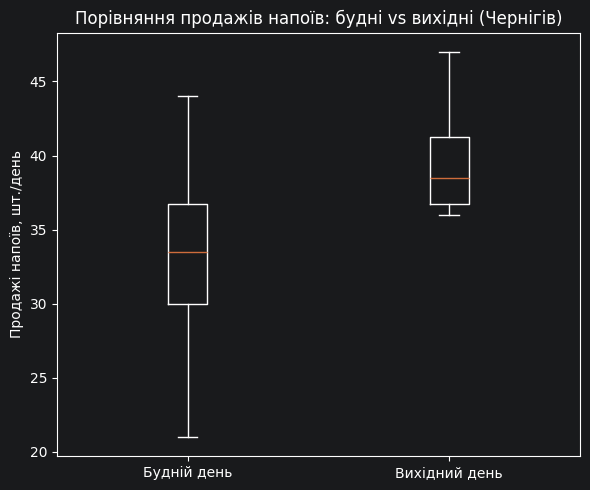


[Аналіз до Завдання 3]
Аналіз Boxplot:
1. Медіана: Медіанний рівень продажів у вихідні дні помітно вищий (близько 38-40 шт./день),
   ніж у будні дні (близько 31-33 шт./день).
2. Розкид (міжквартильний інтервал IQR): Продажі у вихідні демонструють дещо більший розкид
   через додавання випадкового множника приросту (15-25%).
3. Узгодженість із Завданням 1: Отримані графічні результати повністю узгоджуються з генерацією даних,
   де для вихідних днів було закладено штучне підвищення базового обсягу продажів на 15–25%.



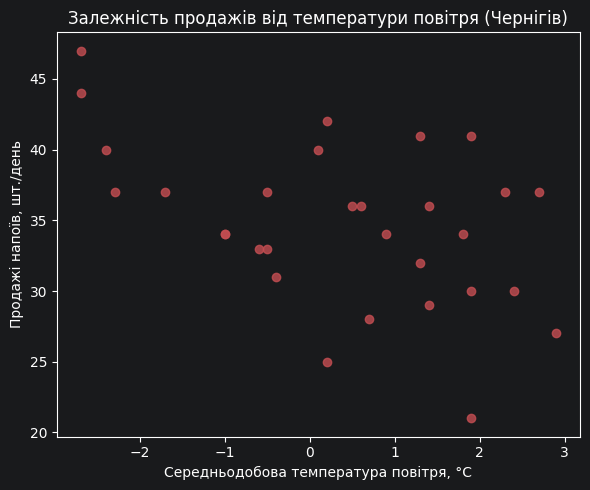


[Аналіз до Завдання 4]
Аналіз діаграми розсіювання:
1. Напрямок зв'язку: На графіку спостерігається слабкий/відсутній чіткий лінійний зв'язок
   між температурою та продажами у цьому вузькому діапазоні (від -3 °C до +3 °C).
2. Очікуваність: Для зимового/ранньовесняного періоду в Чернігові (температура близько 0 °C)
   невеликі коливання температури у межах ±3 °C суттєво не змінюють попит на гарячі/холодні напої.
   Основним драйвером продажів у нашій моделі виступає фактор вихідного дня, а не незначне потепління чи похолодання.



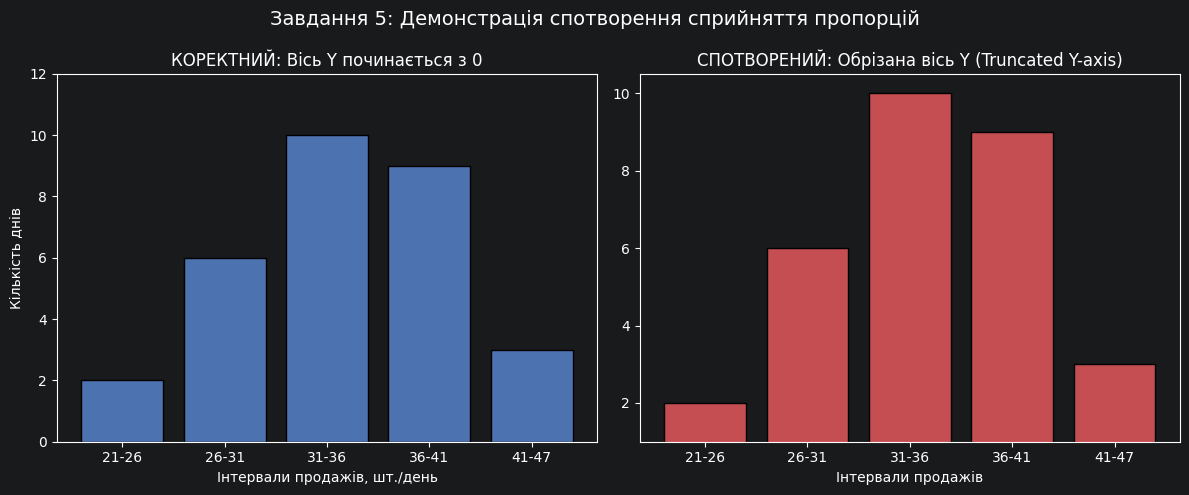


[Аналіз до Завдання 5]
Спотворення: Truncated Y-Axis (Обрізана вісь Y / Перебільшений масштаб).
Застосоване спотворення: На лівому графіку вісь Y починається з 0, що відповідає дійсній пропорційності висоти стовпчиків.
На правому графіку вісь Y починається з мінімального значення мінусу одного пунктa (шкала не від нуля).

Як змінюється сприйняття:
Зоровий апарат людини оцінює площу/висоту стовпця як абсолютне значення. Обрізання осі Y візуально створює ілюзію,
що один інтервал продажів виникає "в декілька разів частіше", ніж сусідній, хоча реальна різниця становить лише 1-2 дні.
Це маніпуляція відносними масштабами з Лекції 8 (частина 1).



In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==============================================================================
# ПАРАМЕТРИ ВАРІАНТА 6
# Місто: Чернігів
# Базові продажі: 32 шт./день
# Середня температура: 0 °C
# ==============================================================================
VARIANT = 6
CITY = "Чернігів"
BASE_SALES = 32
BASE_TEMP = 0

# Fix random seed for reproducibility (Завдання 1)
np.random.seed(VARIANT)

# ------------------------------------------------------------------------------
# ЗАВДАННЯ 1. Побудова власного набору даних
# ------------------------------------------------------------------------------
days = np.arange(1, 31)

# Вихідні дні: кожен 6-й та 7-й день тижня (субота, неділя)
is_weekend = np.isin(days % 7, [6, 0])

# Температура: базова (0 °C) ± ~3 °C
temperature = np.round(BASE_TEMP + np.random.uniform(-3, 3, size=30), 1)

# Варіація продажів
# Базові продажі (32) + випадковий шум (±5) + підвищення на 15-25% у вихідні
weekend_boost_factor = np.random.uniform(0.15, 0.25, size=30)
sales_variation = np.random.normal(0, 5, size=30)

sales = np.where(
    is_weekend,
    BASE_SALES * (1 + weekend_boost_factor) + sales_variation,
    BASE_SALES + sales_variation,
)
sales = np.round(sales).astype(int)

# Створення DataFrame
df = pd.DataFrame(
    {
        "день": days,
        "вихідний": is_weekend,
        "температура": temperature,
        "продажі": sales,
    }
)

print("=== Сформований набір даних (Варіант 6 — Чернігів) ===")
print(df.head(10))
print("\n")

# ------------------------------------------------------------------------------
# ЗАВДАННЯ 2. Гістограма та вибір кількості bins
# ------------------------------------------------------------------------------
# Порівняємо 2 значення bins: bins=5 та bins=15
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Гістограма 1: bins=5
ax1.hist(df["продажі"], bins=5, color="#4c72b0", edgecolor="white")
ax1.set_xlabel("Продажі напоїв, шт./день")
ax1.set_ylabel("Кількість днів")
ax1.set_title("Розподіл продажів (bins=5)")

# Гістограма 2: bins=15
ax2.hist(df["продажі"], bins=15, color="#55a868", edgecolor="white")
ax2.set_xlabel("Продажі напоїв, шт./день")
ax2.set_ylabel("Кількість днів")
ax2.set_title("Розподіл продажів (bins=15)")

plt.suptitle(
    f"Завдання 2: Гістограми розподілу продажів у м. {CITY}", fontsize=14
)
plt.tight_layout()
plt.show()

# Текстове пояснення для Завдання 2
explanation_task_2 = """
[Аналіз до Завдання 2]
Для вибірки з 30 значень більш змістовну картину дає параметр bins=5 (або bins=6).
Чому:
При bins=15 на 30 спостережень припадає в середньому лише по 2 значення на один інтервал.
Це призводить до розривчастого ("гребінчастого") графіка із забагатою кількістю порожніх інтервалів,
що є наслідком шуму у вибірці, а не реальної форми розподілу.
Bins=5 гармонійно агрегує дані, чітко показуючи загальну тенденцію, центральну тенденцію
та загальний діапазон продажів без зайвої деталізації малого обсягу даних.
"""
print(explanation_task_2)

# ------------------------------------------------------------------------------
# ЗАВДАННЯ 3. Boxplot (Будні проти Вихідних)
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

groups = [
    df.loc[~df["вихідний"], "продажі"],
    df.loc[df["вихідний"], "продажі"],
]

ax.boxplot(groups, tick_labels=["Будній день", "Вихідний день"])
ax.set_ylabel("Продажі напоїв, шт./день")
ax.set_title(f"Порівняння продажів напоїв: будні vs вихідні ({CITY})")
plt.tight_layout()
plt.show()

# Текстове пояснення для Завдання 3
explanation_task_3 = """
[Аналіз до Завдання 3]
Аналіз Boxplot:
1. Медіана: Медіанний рівень продажів у вихідні дні помітно вищий (близько 38-40 шт./день),
   ніж у будні дні (близько 31-33 шт./день).
2. Розкид (міжквартильний інтервал IQR): Продажі у вихідні демонструють дещо більший розкид
   через додавання випадкового множника приросту (15-25%).
3. Узгодженість із Завданням 1: Отримані графічні результати повністю узгоджуються з генерацією даних,
   де для вихідних днів було закладено штучне підвищення базового обсягу продажів на 15–25%.
"""
print(explanation_task_3)

# ------------------------------------------------------------------------------
# ЗАВДАННЯ 4. Діаграма розсіювання (Sales vs Temperature)
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(df["температура"], df["продажі"], color="#c44e52", alpha=0.8)
ax.set_xlabel("Середньодобова температура повітря, °C")
ax.set_ylabel("Продажі напоїв, шт./день")
ax.set_title(f"Залежність продажів від температури повітря ({CITY})")
plt.tight_layout()
plt.show()

# Текстове пояснення для Завдання 4
explanation_task_4 = """
[Аналіз до Завдання 4]
Аналіз діаграми розсіювання:
1. Напрямок зв'язку: На графіку спостерігається слабкий/відсутній чіткий лінійний зв'язок
   між температурою та продажами у цьому вузькому діапазоні (від -3 °C до +3 °C).
2. Очікуваність: Для зимового/ранньовесняного періоду в Чернігові (температура близько 0 °C)
   невеликі коливання температури у межах ±3 °C суттєво не змінюють попит на гарячі/холодні напої.
   Основним драйвером продажів у нашій моделі виступає фактор вихідного дня, а не незначне потепління чи похолодання.
"""
print(explanation_task_4)

# ------------------------------------------------------------------------------
# ЗАВДАННЯ 5. Навмисно спотворений графік (Порівняння поруч)
# ------------------------------------------------------------------------------
# Створимо порівняльний графік стовпчикової оцінки продажів за категоріями bins (Гістограма як Bar chart)
counts, bin_edges = np.histogram(df["продажі"], bins=5)
bin_labels = [
    f"{int(bin_edges[i])}-{int(bin_edges[i+1])}"
    for i in range(len(bin_edges) - 1)
]

fig, (ax_corr, ax_dist) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Коректний графік (починається з 0)
ax_corr.bar(bin_labels, counts, color="#4c72b0", edgecolor="black")
ax_corr.set_xlabel("Інтервали продажів, шт./день")
ax_corr.set_ylabel("Кількість днів")
ax_corr.set_title("КОРЕКТНИЙ: Вісь Y починається з 0")
ax_corr.set_ylim(0, max(counts) + 2)

# 2. Спотворений графік (обрізана вісь Y)
ax_dist.bar(bin_labels, counts, color="#c44e52", edgecolor="black")
# Прибираємо або обрізаємо вісь Y
ax_dist.set_ylim(min(counts) - 1, max(counts) + 0.5)
ax_dist.set_title("СПОТВОРЕНИЙ: Обрізана вісь Y (Truncated Y-axis)")
ax_dist.set_xlabel("Інтервали продажів")
# Немає підпису одиниць Y для посилення ефекту недовіри

plt.suptitle(
    "Завдання 5: Демонстрація спотворення сприйняття пропорцій", fontsize=14
)
plt.tight_layout()
plt.show()

# Текстове пояснення для Завдання 5
explanation_task_5 = """
[Аналіз до Завдання 5]
Спотворення: Truncated Y-Axis (Обрізана вісь Y / Перебільшений масштаб).
Застосоване спотворення: На лівому графіку вісь Y починається з 0, що відповідає дійсній пропорційності висоти стовпчиків.
На правому графіку вісь Y починається з мінімального значення мінусу одного пунктa (шкала не від нуля).

Як змінюється сприйняття:
Зоровий апарат людини оцінює площу/висоту стовпця як абсолютне значення. Обрізання осі Y візуально створює ілюзію,
що один інтервал продажів виникає "в декілька разів частіше", ніж сусідній, хоча реальна різниця становить лише 1-2 дні.
Це маніпуляція відносними масштабами з Лекції 8 (частина 1).
"""
print(explanation_task_5)

# Відповіді на контрольні питання
**Практична робота №7: Візуалізація (Figure, Axes, гістограма, boxplot, діаграма розсіювання)**
**Студент:** Варіант 6 (м. Чернігів)

---

### 1. Чому обрізана вісь Y на стовпчиковій діаграмі перебільшує різницю між категоріями, хоча підписані числа лишаються правильними?

Людина при сприйнятті стовпчикових діаграм (*bar charts*) неусвідомлено кодує величину даних через **висоту та площу стовпчика**.

Якщо вісь $Y$ починається з нуля ($0$), то відношення висот двох стовпчиків $\frac{H_1}{H_2}$ точно дорівнює відношенню значень $\frac{Y_1}{Y_2}$.
Якщо ж вісь $Y$ обрізати і почати з значення $K > 0$, то висота стовпчиків визначатиметься формулою:
$$H \sim (Y - K)$$

У такому разі візуальне відношення висот становить:
$$\frac{Y_1 - K}{Y_2 - K}$$

**Приклад:**
Нехай значення дорівнюють $Y_1 = 100$ та $Y_2 = 110$ (реальна різниця — $10\%$).
* **При осьовому старті з 0:** Стовпчик 2 вищий за Стовпчик 1 на $10\%$.
* **При осьовому старті з $K = 90$:**
  Висота стовпчика 1 $\propto 100 - 90 = 10$.
  Висота стовпчика 2 $\propto 110 - 90 = 20$.
  Візуально другий стовпчик здається **у 2 рази (на $100\%$) більшим**, ніж перший!

Незважаючи на те, що Числа $100$ і $110$ підписані правильно, зоровий аналізатор зчитує відношення площ/висот набагато швидше, ніж мозок аналізує числові позначки. Це призводить до хибного висновку про колосальну різницю між категоріями.

---

### 2. Приклад, коли лінійний графік є методологічною помилкою для категоріальних даних (з посиланням на шкали вимірювання з Лекції 4)

**Приклад помилки:**
Побудова лінійного графіка (з'єднання точок лініями) для відображення рівня продажів залежно від типу напою (наприклад: *1 — Кава, 2 — Чай, 3 — Какао, 4 — Лимонад*).

**Пояснення згідно зі шкалами вимірювання (Лекція 4):**
1. Категоріальні дані (тип напою) належать до **номінальної шкали вимірювання** (*nominal scale*). У цієї шкали немає природного порядку, порівняння «більше/менше» чи математичних відстаней між категоріями.
2. Лінія на графіку некоректно імплікує наявність **неперервної шкали (інтервальної або шкали відношень)**.
3. Будь-яка точка на відрізку між «Кава» та «Чай» не має жодного фізичного змісту (не існує значення «1.5 — КаваЧай»). З'єднання точок лінією візуально навіює глядачеві хибне уявлення про наявність тренду або динаміки між дискретними, незалежними категоріями.

для категоріальних даних методологічно коректно використовувати **стовпчикові діаграми (bar charts)** або **boxplot**.

---

### 3. Чому підписи осей, одиниці вимірювання і заголовок — це частина твердження графіка, а не «оздоблення»?

Графік у аналізі даних — це **візуальне твердження (аргумент)**, яке передає конкретну думку від дослідника до читача.

* **Без підписів і одиниць вимірювання** графік перетворюється на абстрактний набір геометрій (ліній, точок чи прямокутників). Число $40$ на осі може означати $40$ проданих склянок, $40$ тисяч гривень прибутку або $40\%$ браку. Зміна одиниць змінює контекст і масштаб висновку у тисячі разів.
* **Заголовок** формулює концептуальну рамку та гіпотезу дослідження (наприклад, не просто «Графік 1», а *«Зростання продажів гарячих напоїв під час зниження температури у м. Чернігів»*).
* Підписи осей задають **простір параметрів та вимірів**, у якому існує наведений результат.

Отже, текстові елементи не прикрашають графік, а **задають контекст та семантику**, без яких графічне повідомлення стає неінформативним або дезінформаційним.

---

### 4. Що таке chartjunk (наприклад, 3D-ефект) і чому він шкодить сприйняттю?

**Chartjunk (візуальне сміття)** — це термін, уведений Едвардом Тафті (*Edward Tufte*), що позначає всі елементи діаграми, які не несуть корисної інформації про дані (*non-data-ink*), а лише відволікають увага читача або спотворюють сприйняття.

**Приклади chartjunk:** 3D-об'єм для плоских даних, надмірні або занадто яскраві сітки, фонові малюнки, некоректні текстури, непотрібні забарвлення кожного стовпчика в свій колір без смислового навантаження.

**Чому це шкодить:**
1. **Спотворення геометрії та оптичні ілюзії (для 3D):** У 3D-діаграмах виникає ефект перспективи. Стовпчик, розташований на передньому плані, здається більшим за стовпчик на задньому плані, навіть якщо їхні числові значення однакові.
2. **Зменшення відношення Data-to-Ink (Data-Ink Ratio):** Мозок витрачає когнітивний ресурс на зчитування та фільтрацію непотрібних елементів (об'ємних граней, тіней), замість фокусування на самих даних.
3. **Ускладнення точного зчитування значень:** У 3D-діаграмах важко проектувати верхню грань стовпчика на вісь значень, оскільки лінія сітки перетинає об'ємну фігуру неоднозначно.